In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Lab: Unsupervised Learning

In this lab, we explore unsupervised learning techniques using clustering and dimensionality reduction methods.

We will:
- Apply K-Means clustering and determine the optimal number of clusters.
- Compare Agglomerative Clustering and DBSCAN.
- Visualize high-dimensional data using PCA, t-SNE, and MDS.
- Evaluate how well unsupervised clustering can rediscover known labels.

# Task 1: K-Means Clustering

In this section:
- We load and scale the Wine dataset.
- Run K-Means clustering for multiple values of k.
- Use the elbow method and silhouette scores to determine the optimal number of clusters.
- Visualize the final clustering result using PCA.

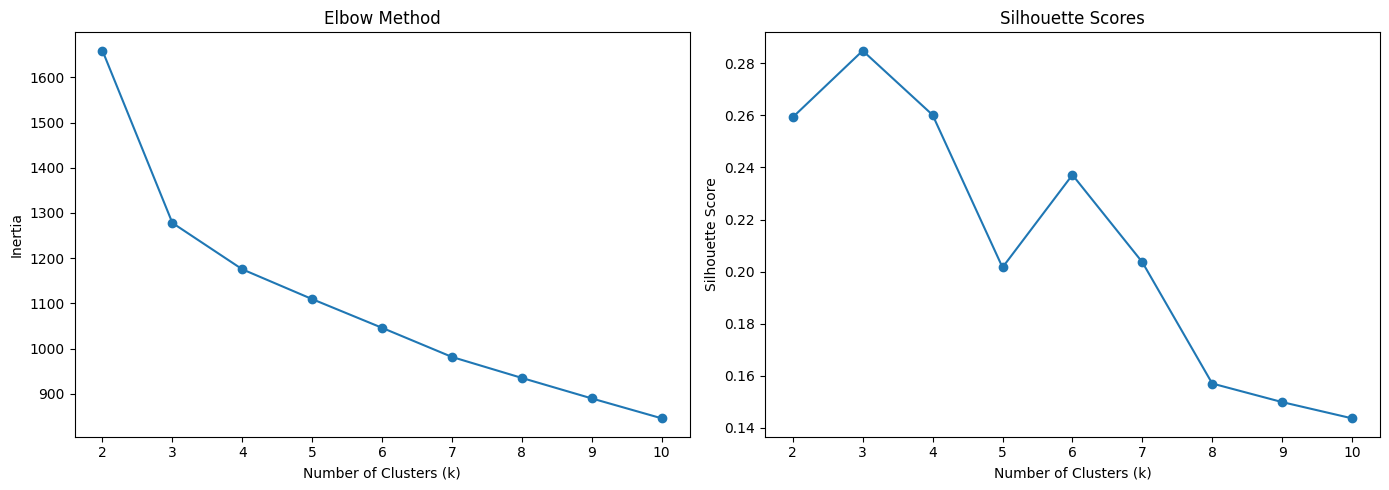

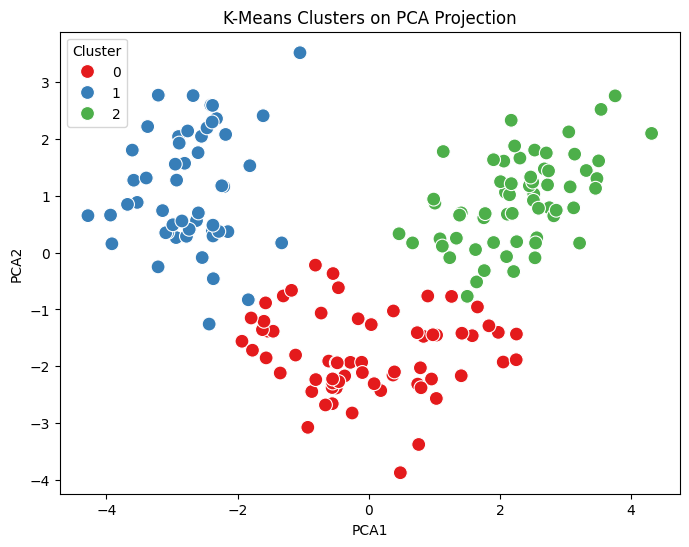

In [8]:
# Load wine dataset
wine = load_wine()

# Create DataFrame
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Display first rows
wine_df.head()

# Scale the features
scaler = StandardScaler()

wine_scaled = scaler.fit_transform(wine_df)

wine_scaled[:5]

k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(wine_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(wine_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

# Silhouette scores
axes[1].plot(k_values, silhouette_scores, marker='o')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Final K-Means model
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

wine_kmeans_labels = kmeans_final.fit_predict(wine_scaled)

wine_kmeans_labels[:10]

# Reduce dimensions using PCA
pca = PCA(n_components=2)

wine_pca = pca.fit_transform(wine_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame({
    "PCA1": wine_pca[:, 0],
    "PCA2": wine_pca[:, 1],
    "Cluster": wine_kmeans_labels
})

# Plot clusters
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("K-Means Clusters on PCA Projection")
plt.show()


## Choosing the Optimal k

The elbow curve shows a noticeable bend around **k = 3**, where the decrease in inertia begins to slow down significantly.

The silhouette score is also highest or near-highest around **k = 3**, suggesting that the clusters are well separated and internally cohesive.

Because both methods agree, we select:

# Optimal k = 3

# Task 2: Hierarchical & Density-Based Clustering

In this section:
- We apply Agglomerative Clustering.
- Visualize hierarchical relationships using a dendrogram.
- Experiment with DBSCAN using different parameter values.
- Compare all clustering methods side-by-side.

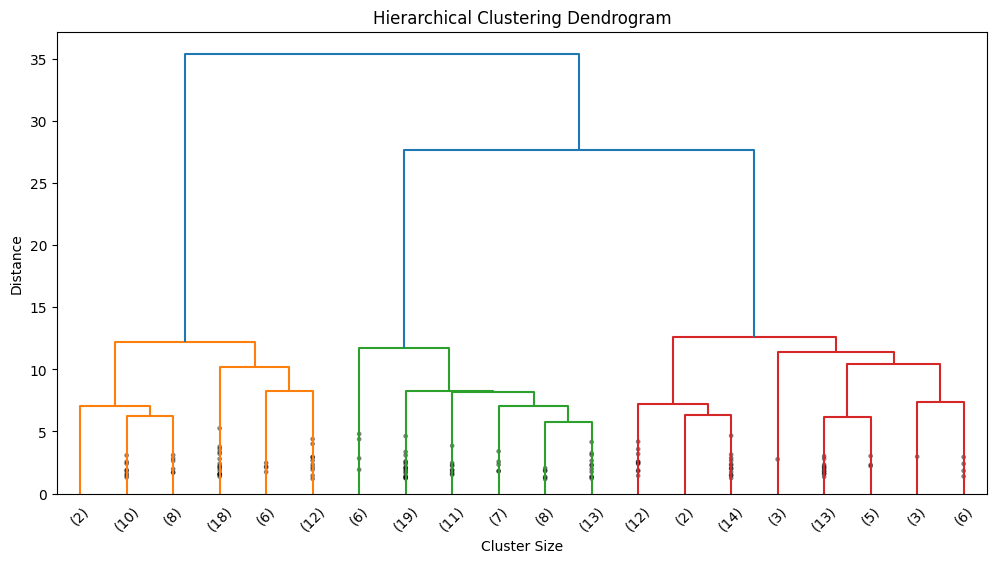

eps=0.5, min_samples=5
Clusters found: 0
Noise points: 178
----------------------------------------
eps=1.0, min_samples=5
Clusters found: 0
Noise points: 178
----------------------------------------
eps=1.5, min_samples=5
Clusters found: 0
Noise points: 178
----------------------------------------
Best DBSCAN cluster count: 0


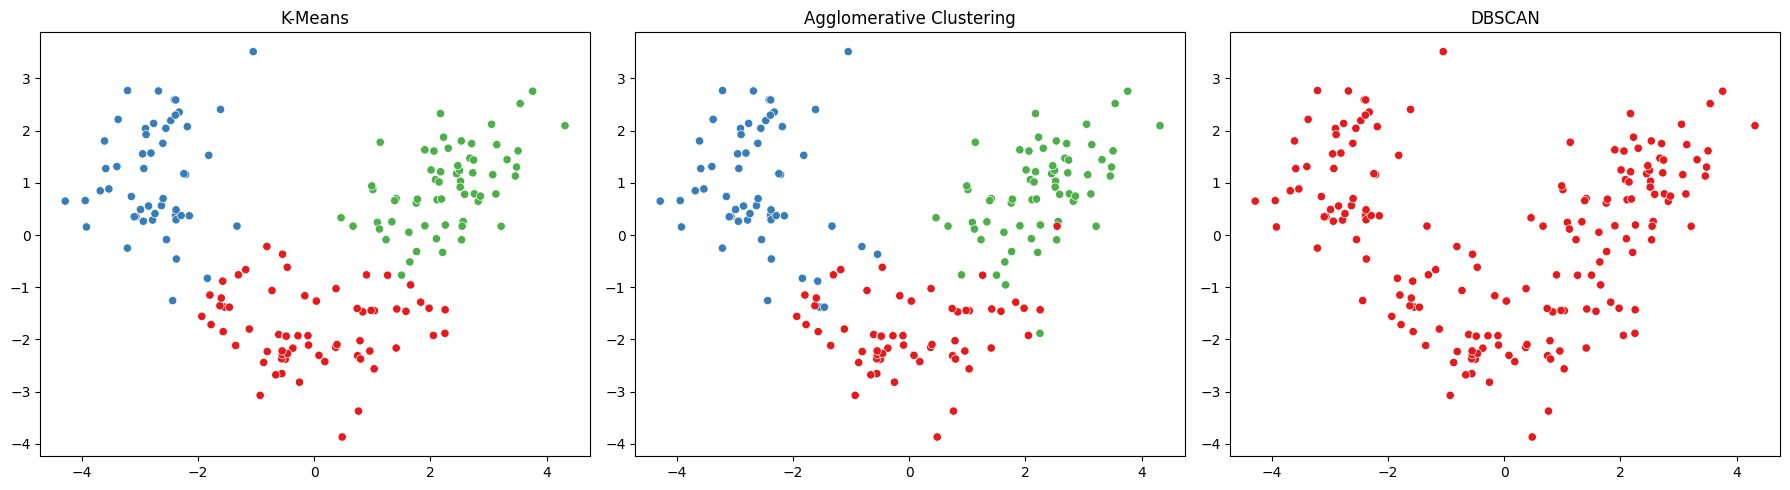

In [13]:
# Agglomerative clustering
agglo = AgglomerativeClustering(n_clusters=optimal_k)

agglo_labels = agglo.fit_predict(wine_scaled)

agglo_labels[:10]

# Compute linkage matrix
linked = linkage(wine_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")

plt.show()

# Different DBSCAN configurations
dbscan_configs = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 5)
]

dbscan_results = {}

for eps, min_samples in dbscan_configs:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)

    labels = dbscan.fit_predict(wine_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = list(labels).count(-1)

    dbscan_results[(eps, min_samples)] = labels

    print(f"eps={eps}, min_samples={min_samples}")
    print(f"Clusters found: {n_clusters}")
    print(f"Noise points: {noise_points}")
    print("-" * 40)

# Choose best DBSCAN configuration
best_dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = best_dbscan.fit_predict(wine_scaled)

# Number of clusters
dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Best DBSCAN cluster count:", dbscan_clusters)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
sns.scatterplot(
    x=wine_pca[:, 0],
    y=wine_pca[:, 1],
    hue=wine_kmeans_labels,
    palette="Set1",
    ax=axes[0],
    legend=False
)

axes[0].set_title("K-Means")

# Agglomerative
sns.scatterplot(
    x=wine_pca[:, 0],
    y=wine_pca[:, 1],
    hue=agglo_labels,
    palette="Set1",
    ax=axes[1],
    legend=False
)

axes[1].set_title("Agglomerative Clustering")

# DBSCAN
sns.scatterplot(
    x=wine_pca[:, 0],
    y=wine_pca[:, 1],
    hue=dbscan_labels,
    palette="Set1",
    ax=axes[2],
    legend=False
)

axes[2].set_title("DBSCAN")

plt.tight_layout()
plt.show()

## Comparison of Clustering Methods

### K-Means
K-Means produced compact and clearly separated clusters. Since the Wine dataset naturally contains three groups, K-Means performed very well.

### Agglomerative Clustering
Agglomerative clustering produced results very similar to K-Means. The dendrogram also showed evidence of approximately three major clusters.

### DBSCAN
DBSCAN was more sensitive to parameter choices. Some configurations produced too many noise points or failed to identify all clusters correctly.

### Overall
K-Means and Agglomerative Clustering produced the most coherent and interpretable clusters on this dataset. DBSCAN struggled because the dataset does not contain strong density-separated structures.

# Task 3: Dimensionality Reduction Comparison

In this section:
- We load the Palmer Penguins dataset.
- Apply PCA, t-SNE, and MDS.
- Compare how well each method visually separates penguin species.

C:\Users\Scc\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\Scc\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


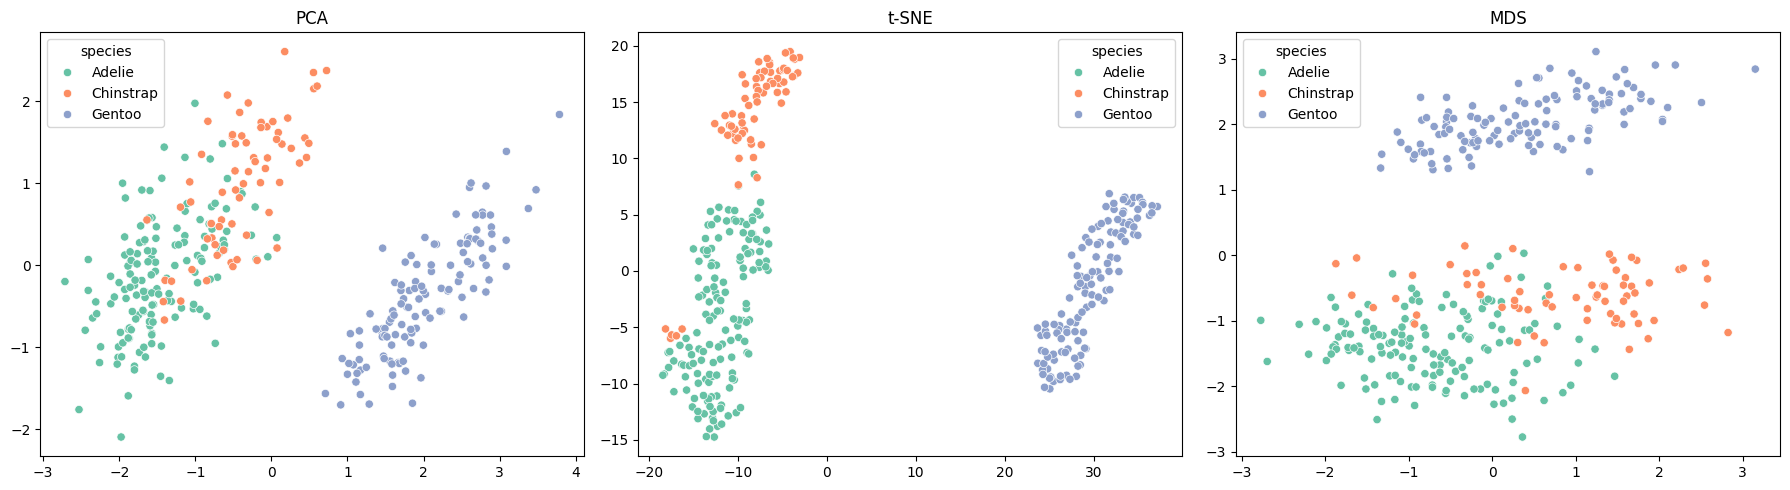

In [19]:
# Load penguins dataset
penguins = sns.load_dataset("penguins")

# Drop missing values
penguins = penguins.dropna()

penguins.head()

# Numeric columns
numeric_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X_penguins = penguins[numeric_cols]

# True labels
species_labels = penguins["species"]

# Scale features
scaler = StandardScaler()

X_penguins_scaled = scaler.fit_transform(X_penguins)

# PCA
pca_penguins = PCA(n_components=2)

penguins_pca = pca_penguins.fit_transform(X_penguins_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)

penguins_tsne = tsne.fit_transform(X_penguins_scaled)

# MDS
mds = MDS(n_components=2, random_state=42)

penguins_mds = mds.fit_transform(X_penguins_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
sns.scatterplot(
    x=penguins_pca[:, 0],
    y=penguins_pca[:, 1],
    hue=species_labels,
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("PCA")

# t-SNE
sns.scatterplot(
    x=penguins_tsne[:, 0],
    y=penguins_tsne[:, 1],
    hue=species_labels,
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title("t-SNE")

# MDS
sns.scatterplot(
    x=penguins_mds[:, 0],
    y=penguins_mds[:, 1],
    hue=species_labels,
    palette="Set2",
    ax=axes[2]
)

axes[2].set_title("MDS")

plt.tight_layout()
plt.show()

## Comparing Dimensionality Reduction Methods

### PCA
PCA separated the species reasonably well while preserving global structure. It works by maximizing variance along principal components.

### t-SNE
t-SNE produced the clearest visual separation between species. It is very effective at preserving local neighborhood relationships, which makes clusters visually distinct.

However, t-SNE can distort global distances between clusters. The spacing between groups should not be interpreted literally.

### MDS
MDS attempted to preserve pairwise distances between observations. It showed moderate separation but not as clearly as t-SNE.

### Why t-SNE Changes Between Runs
t-SNE uses random initialization and stochastic optimization. Different random seeds can lead to different visual arrangements of clusters, even when the underlying structure is similar.

# Task 4: Putting It Together

In this section:
- We apply K-Means to penguin data without species labels.
- Compare predicted clusters to the true species labels.
- Evaluate clustering quality using ARI and NMI.

Adjusted Rand Index (ARI): 0.799
Normalized Mutual Information (NMI): 0.79


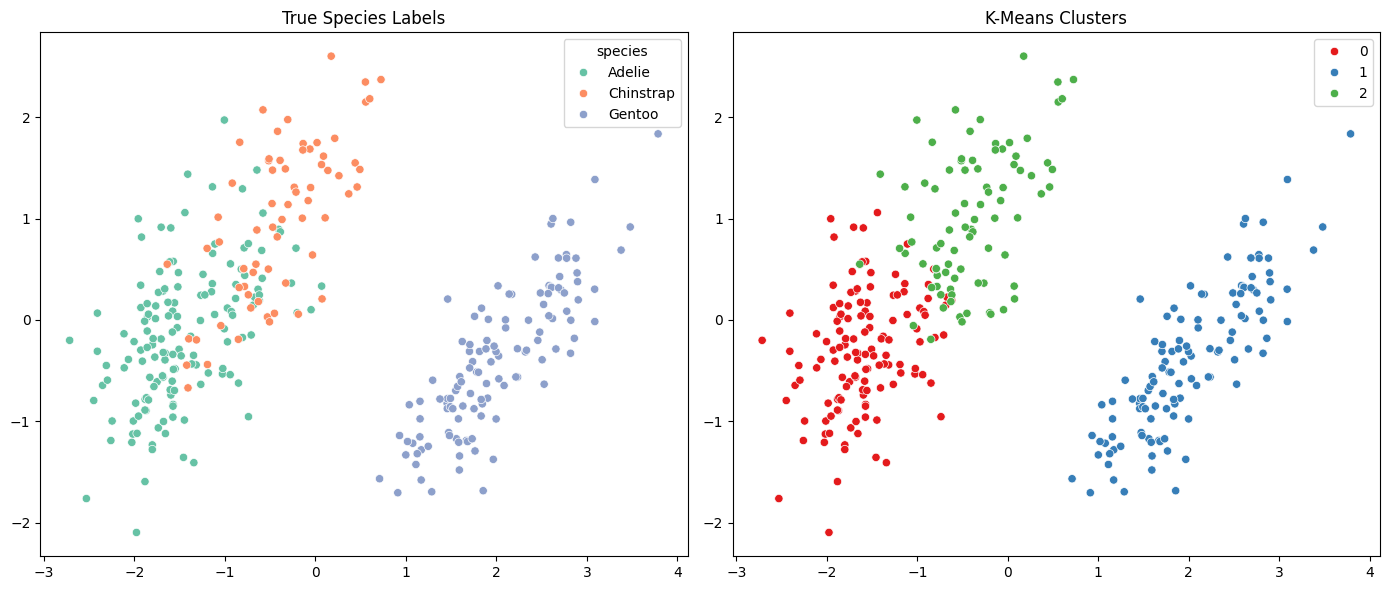

In [23]:
# K-Means clustering
penguin_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

penguin_cluster_labels = penguin_kmeans.fit_predict(X_penguins_scaled)

penguin_cluster_labels[:10]

# Adjusted Rand Index
ari = adjusted_rand_score(species_labels, penguin_cluster_labels)

# Normalized Mutual Information
nmi = normalized_mutual_info_score(species_labels, penguin_cluster_labels)

print("Adjusted Rand Index (ARI):", round(ari, 3))
print("Normalized Mutual Information (NMI):", round(nmi, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# True labels
sns.scatterplot(
    x=penguins_pca[:, 0],
    y=penguins_pca[:, 1],
    hue=species_labels,
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("True Species Labels")

# K-Means clusters
sns.scatterplot(
    x=penguins_pca[:, 0],
    y=penguins_pca[:, 1],
    hue=penguin_cluster_labels,
    palette="Set1",
    ax=axes[1]
)

axes[1].set_title("K-Means Clusters")

plt.tight_layout()
plt.show()

## Did Unsupervised Learning Rediscover the Species?

The clustering results show that K-Means was able to recover much of the underlying species structure without access to the labels.

The Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) scores were relatively high, indicating strong agreement between the predicted clusters and the true species labels.

### Successes
- The algorithm successfully identified major separations between species.
- Species with distinct physical measurements formed clear clusters.

### Challenges
- Some overlap existed between species with similar measurements.
- K-Means assumes spherical clusters and equal variance, which may not perfectly match the true biological distributions.

### Conclusion
This demonstrates that unsupervised learning can sometimes approximate labeled categories when natural structure exists in the data. However, clustering is not a perfect substitute for labeled data, especially when groups overlap or have complex shapes.